In [1]:
import time
import csv
import re
from pathlib import Path
from datetime import datetime

import numpy as np
import pyvisa
import matplotlib.pyplot as plt

In [2]:
RESOURCE = "GPIB0::24::INSTR"

# Measurement settings
bias_voltage = 3.0          # volts
total_time_s = 30           # total measurement time in seconds
sample_interval_s = 0.1     # time between readings

# Safety
current_compliance = 0.01   # 10 mA

# Save folder
save_folder = Path.home() / "Downloads"
save_folder.mkdir(parents=True, exist_ok=True)

base_name = input("Enter filename, no extension: ").strip()
if base_name == "":
    base_name = "keithley_current_vs_time"

base_name = re.sub(r"[^\w\-]", "_", base_name)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_filename = save_folder / f"{base_name}_{timestamp}.csv"

print("Data will save to:")
print(save_filename)

Enter filename, no extension:  CdSe_CdS_Mn_Doped_3V_1080nm_PostSPLE


Data will save to:
C:\Users\414824\Downloads\CdSe_CdS_Mn_Doped_3V_1080nm_PostSPLE_20260505_150135.csv


In [3]:
rm = pyvisa.ResourceManager()

print("VISA backend:", rm.visalib)
print("Available resources:", rm.list_resources())

smu = rm.open_resource(RESOURCE)
smu.timeout = 10000
smu.write_termination = "\n"
smu.read_termination = "\n"
smu.write(":SENS:CURR:NPLC 0.01")

print("Connected to:", smu.query("*IDN?").strip())

VISA backend: Visa Library at C:\windows\system32\visa32.dll
Available resources: ('ASRL3::INSTR', 'GPIB0::24::INSTR')
Connected to: KEITHLEY INSTRUMENTS INC.,MODEL 2400,4000292,C32   Oct  4 2010 14:20:11/A02  /S/K


In [4]:
smu.write("*RST")
time.sleep(0.5)

smu.write(":SOUR:FUNC VOLT")
smu.write(":SOUR:VOLT:MODE FIX")
smu.write(f":SOUR:VOLT {bias_voltage}")

smu.write(":SENS:FUNC 'CURR'")
smu.write(f":SENS:CURR:PROT {current_compliance}")

# Return voltage and current
smu.write(":FORM:ELEM VOLT,CURR")

print("Keithley initialized.")
print(f"Bias voltage: {bias_voltage} V")
print(f"Current compliance: {current_compliance} A")

Keithley initialized.
Bias voltage: 3.0 V
Current compliance: 0.01 A


Keithley output turned OFF.
Collected 206 data points.


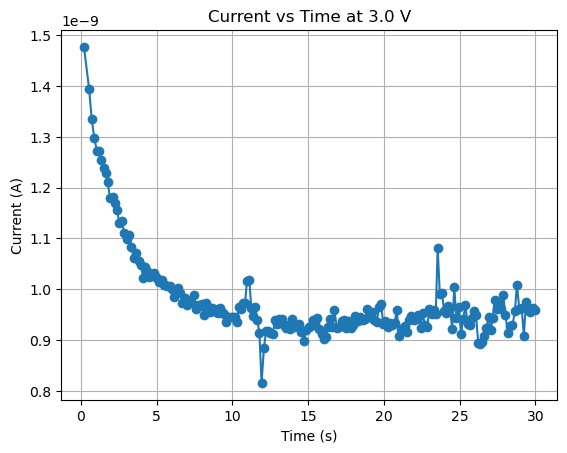

In [5]:
elapsed_time = []
measured_v = []
measured_i = []

plt.ion()
fig, ax = plt.subplots()
line, = ax.plot([], [], marker="o")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Current (A)")
ax.set_title(f"Current vs Time at {bias_voltage} V")
ax.grid(True)

start_time = time.time()
next_sample_time = start_time

try:
    smu.write(":OUTP ON")
    time.sleep(0.2)

    while True:
        now = time.time()
        t_elapsed = now - start_time

        if t_elapsed >= total_time_s:
            break

        if now >= next_sample_time:
            response = smu.query(":READ?").strip()
            vals = [float(x) for x in response.split(",")[:2]]

            v_meas = vals[0]
            i_meas = vals[1]

            elapsed_time.append(t_elapsed)
            measured_v.append(v_meas)
            measured_i.append(i_meas)

            line.set_xdata(elapsed_time)
            line.set_ydata(measured_i)
            ax.relim()
            ax.autoscale_view()
            fig.canvas.draw()
            fig.canvas.flush_events()

            next_sample_time += sample_interval_s

        time.sleep(0.01)

except Exception as e:
    print("Measurement error:", e)

finally:
    smu.write(":SOUR:VOLT 0")
    time.sleep(0.2)
    smu.write(":OUTP OFF")
    print("Keithley output turned OFF.")
    print(f"Collected {len(elapsed_time)} data points.")

In [6]:
if len(elapsed_time) == 0:
    print("No data to save. Run the measurement cell first.")
else:
    with open(save_filename, "w", newline="") as f:
        writer = csv.writer(f)

        writer.writerow([
            "Time_s",
            "Voltage_V",
            "Current_A",
            "Bias_Setpoint_V",
            "Current_Compliance_A"
        ])

        for t, v, i in zip(elapsed_time, measured_v, measured_i):
            writer.writerow([
                t,
                v,
                i,
                bias_voltage,
                current_compliance
            ])

    print(f"Data saved to: {save_filename}")

Data saved to: C:\Users\414824\Downloads\CdSe_CdS_Mn_Doped_3V_1080nm_PostSPLE_20260505_150135.csv


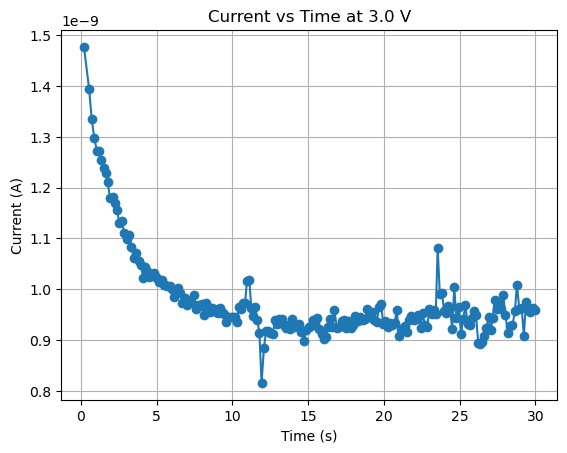

In [7]:
if len(elapsed_time) == 0:
    print("No data to plot. Run the measurement cell first.")
else:
    plt.ioff()
    plt.figure()
    plt.plot(elapsed_time, measured_i, marker="o")
    plt.xlabel("Time (s)")
    plt.ylabel("Current (A)")
    plt.title(f"Current vs Time at {bias_voltage} V")
    plt.grid(True)
    plt.show()

In [8]:
smu.write(":SOUR:VOLT 0")
smu.write(":OUTP OFF")
print("Keithley output OFF.")

Keithley output OFF.
